**SetUp**

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
from src import config
from src.data import loader
from src.predict import load_best_model, load_class_names, predict_image
from src.explainability.gradcam import make_gradcam_heatmap, plot_gradcam

model = load_best_model()
class_names = load_class_names()
_, _, test_df = loader.create_splits(save=False)

SAMPLES_DIR = config.PROJECT_ROOT / "results" / "predictions" / "sample_predictions"
SAMPLES_DIR.mkdir(parents=True, exist_ok=True)


def explain(row, tag):
    """Predict one test image and show prediction + Grad-CAM."""
    result = predict_image(model, Path(row["filepath"]).read_bytes(), class_names)
    heatmap, _, _ = make_gradcam_heatmap(model, result["image"])
    title = (f"True: {row['class']} | Predicted: {result['predicted_class']} "
             f"({result['confidence'] * 100:.1f}%)")
    plot_gradcam(result["image"], heatmap, title, SAMPLES_DIR / f"gradcam_{tag}.png")
    for name, p in sorted(result["probabilities"].items(), key=lambda kv: -kv[1]):
        print(f"  {name:12s} {p * 100:5.1f}%")

**One random test image per class**

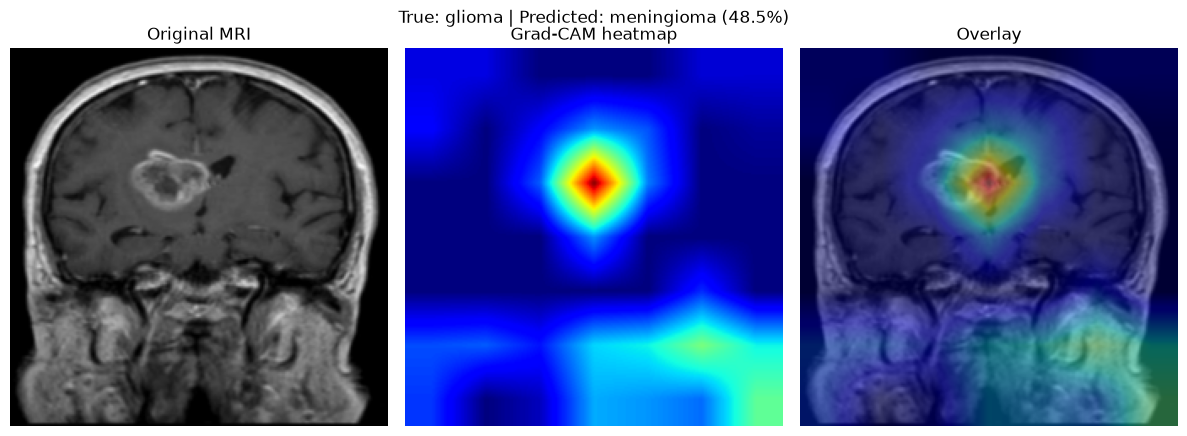

  meningioma    48.5%
  pituitary     40.0%
  notumor        8.4%
  glioma         3.2%


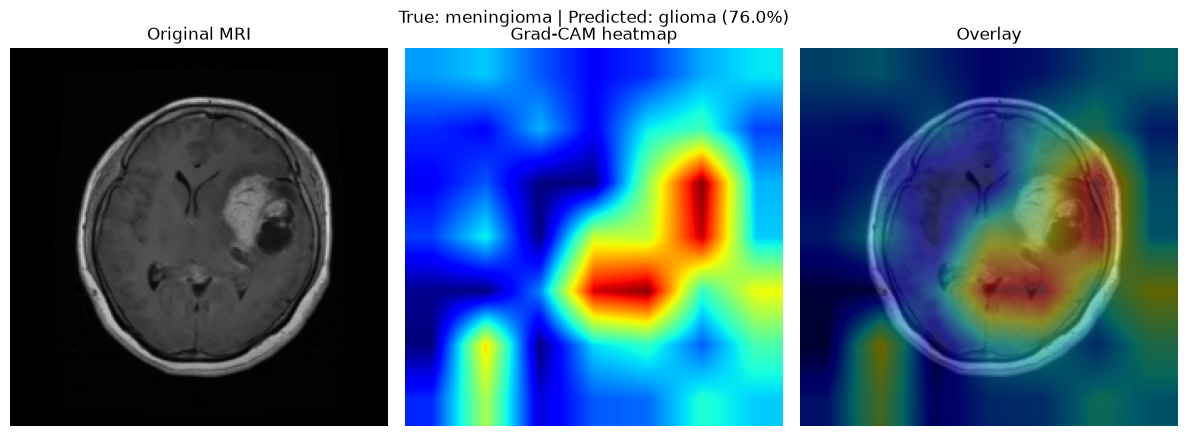

  glioma        76.0%
  meningioma    18.6%
  pituitary      5.1%
  notumor        0.4%


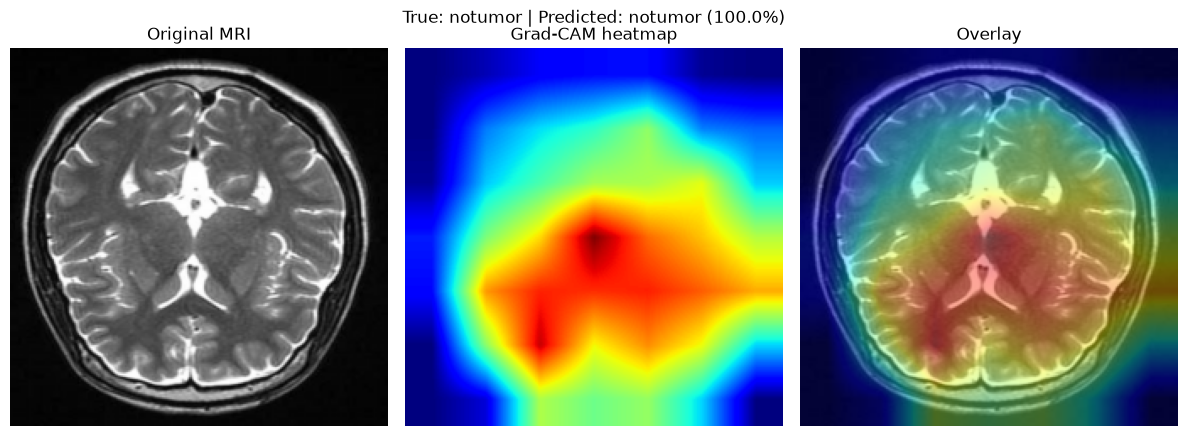

  notumor      100.0%
  glioma         0.0%
  meningioma     0.0%
  pituitary      0.0%


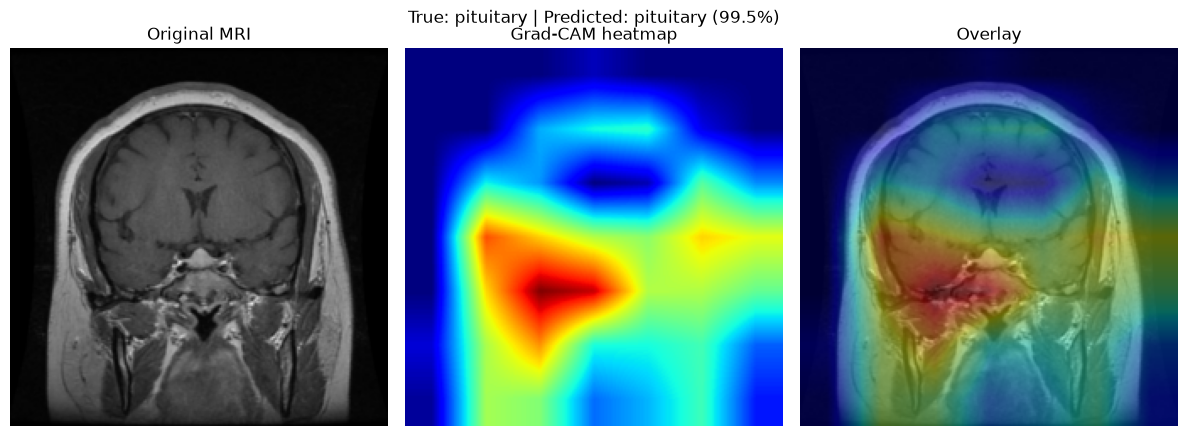

  pituitary     99.5%
  meningioma     0.5%
  notumor        0.0%
  glioma         0.0%


In [2]:
for class_name in class_names:
    row = test_df[test_df["class"] == class_name].sample(1, random_state=7).iloc[0]
    explain(row, class_name)

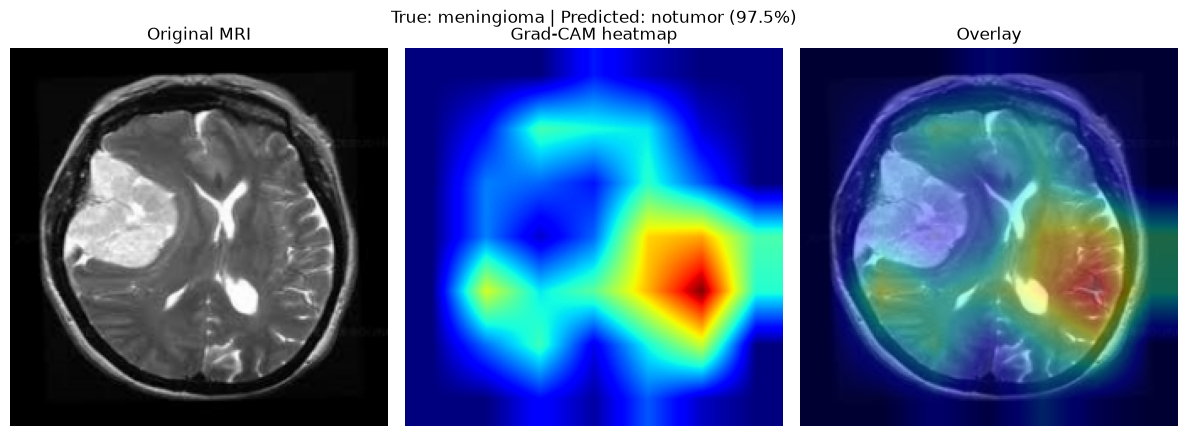

  notumor       97.5%
  meningioma     1.7%
  glioma         0.8%
  pituitary      0.0%


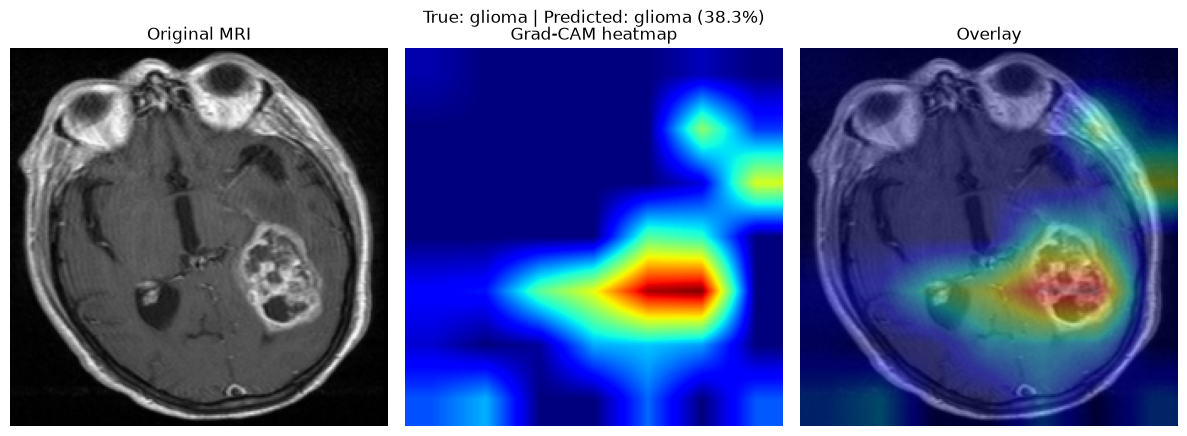

  glioma        38.3%
  meningioma    31.2%
  pituitary     24.5%
  notumor        5.9%


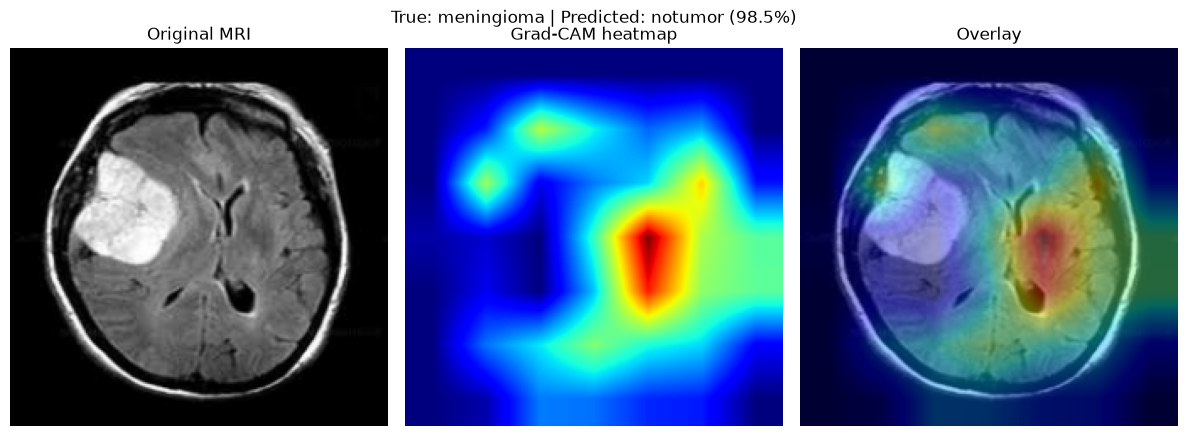

  notumor       98.5%
  meningioma     1.4%
  glioma         0.0%
  pituitary      0.0%


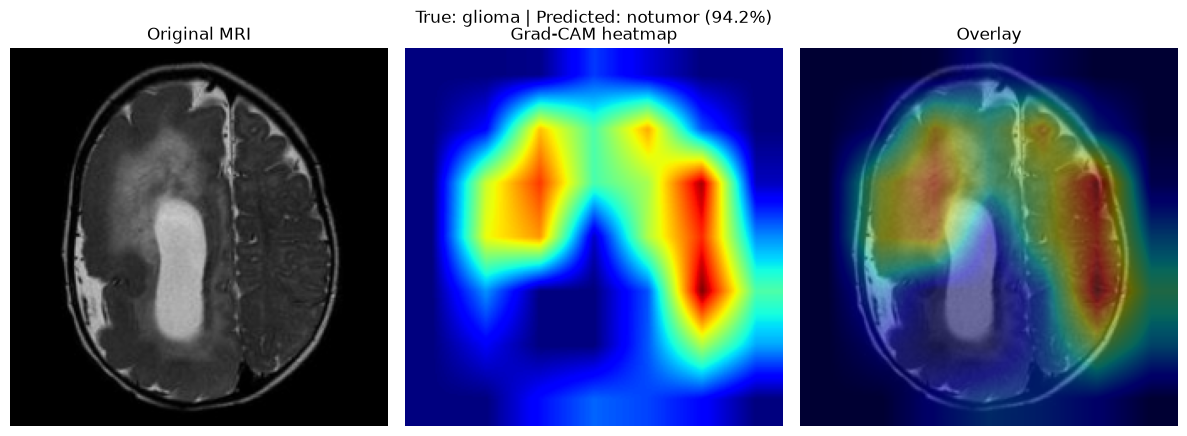

  notumor       94.2%
  meningioma     5.3%
  glioma         0.5%
  pituitary      0.0%


In [3]:
odd_size = ~((test_df["width"] == 512) & (test_df["height"] == 512))
subset = test_df[test_df["class"].isin(["glioma", "meningioma"]) & odd_size]
for i, (_, row) in enumerate(subset.sample(4, random_state=3).iterrows()):
    explain(row, f"non512_{i}")

In [4]:
#Grad-CAM is a model explanation. A highlighted region shows what influenced the model, not where the tumor really is.